In [ ]:
import os
import sys
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

API_BASE = "http://localhost:8000"
PLOT_DIR = "../notebooks/plots/explainability/"
os.makedirs(PLOT_DIR, exist_ok=True)

# Test backend connection framework
try:
    health_status = requests.get(f"{API_BASE}/health").json()
    print(f"API Server Connection Successful: {health_status}")
except Exception as e:
    print(f"Warning: API server at {API_BASE} is unreachable. Ensure the FastAPI server is initialized.\nError: {e}")

SAMPLE_TEXTS = [
    {"text": "these immigrants are ruining our country", "expected": "hate"},
    {"text": "you stupid idiot why would you do that", "expected": "offensive"},
    {"text": "the weather is nice today", "expected": "normal"},
    {"text": "tumlog gande aadmi ho bhai", "expected": "offensive"}, 
    {"text": "tum bade aadmi ho bhai", "expected": "normal"},      
    {"text": "ye log desh ke dushman hain", "expected": "hate"},    
    {"text": "I love this movie it was amazing", "expected": "normal"},
    {"text": "these people are terrorists", "expected": "hate"},
    {"text": "shut up you moron", "expected": "offensive"},
    {"text": "aaj ka din bahut accha tha", "expected": "normal"}    
]

matplotlib.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": matplotlib.cycler(color=["#111111","#555555","#999999","#CCCCCC"]),
    "hatch.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

def predict(text):
    response = requests.post(f"{API_BASE}/predict", json={"text": text})
    return response.json()

def explain(text):
    response = requests.post(f"{API_BASE}/explain", json={"text": text})
    return response.json()

API Server Connection Successful: {'status': 'model_not_loaded', 'model_loaded': False, 'model_name': 'google/muril-base-cased', 'gpu_available': True, 'gpu_name': 'NVIDIA GeForce RTX 3050 Laptop GPU', 'latency_ms': 0.05}


,Text String Sample,Assigned Label,Confidence,Top 3 Attention Tokens
0,these immigrants are ruining our country,hate,0.4780,"are: (1.000), immigrants: (0.903), these: (0.617)"
1,you stupid idiot why would you do that,offensive,0.7865,"you: (1.000), stupid: (0.853), idiot: (0.455)"
2,the weather is nice today,normal,0.9285,"today: (1.000), weather: (0.536), is: (0.229)"
3,tumlog gande aadmi ho bhai,normal,0.7691,"gande: (1.000), tumlog: (0.288), bhai: (0.089)"
4,tum bade aadmi ho bhai,normal,0.9243,"aadmi: (1.000), bhai: (0.508), tum: (0.390)"
5,ye log desh ke dushman hain,normal,0.9134,"dushman: (1.000), hain: (0.741), desh: (0.223)"
6,I love this movie it was amazing,normal,0.9283,"this: (1.000), movie: (0.936), love: (0.835)"
7,these people are terrorists,normal,0.9123,"terrorists: (1.000), are: (0.374), people: (0...."
8,shut up you moron,offensive,0.5348,"shut: (1.000), moron: (0.762), you: (0.138)"
9,aaj ka din bahut accha tha,normal,0.9239,"tha: (1.000), accha: (0.292), bahut: (0.247)"


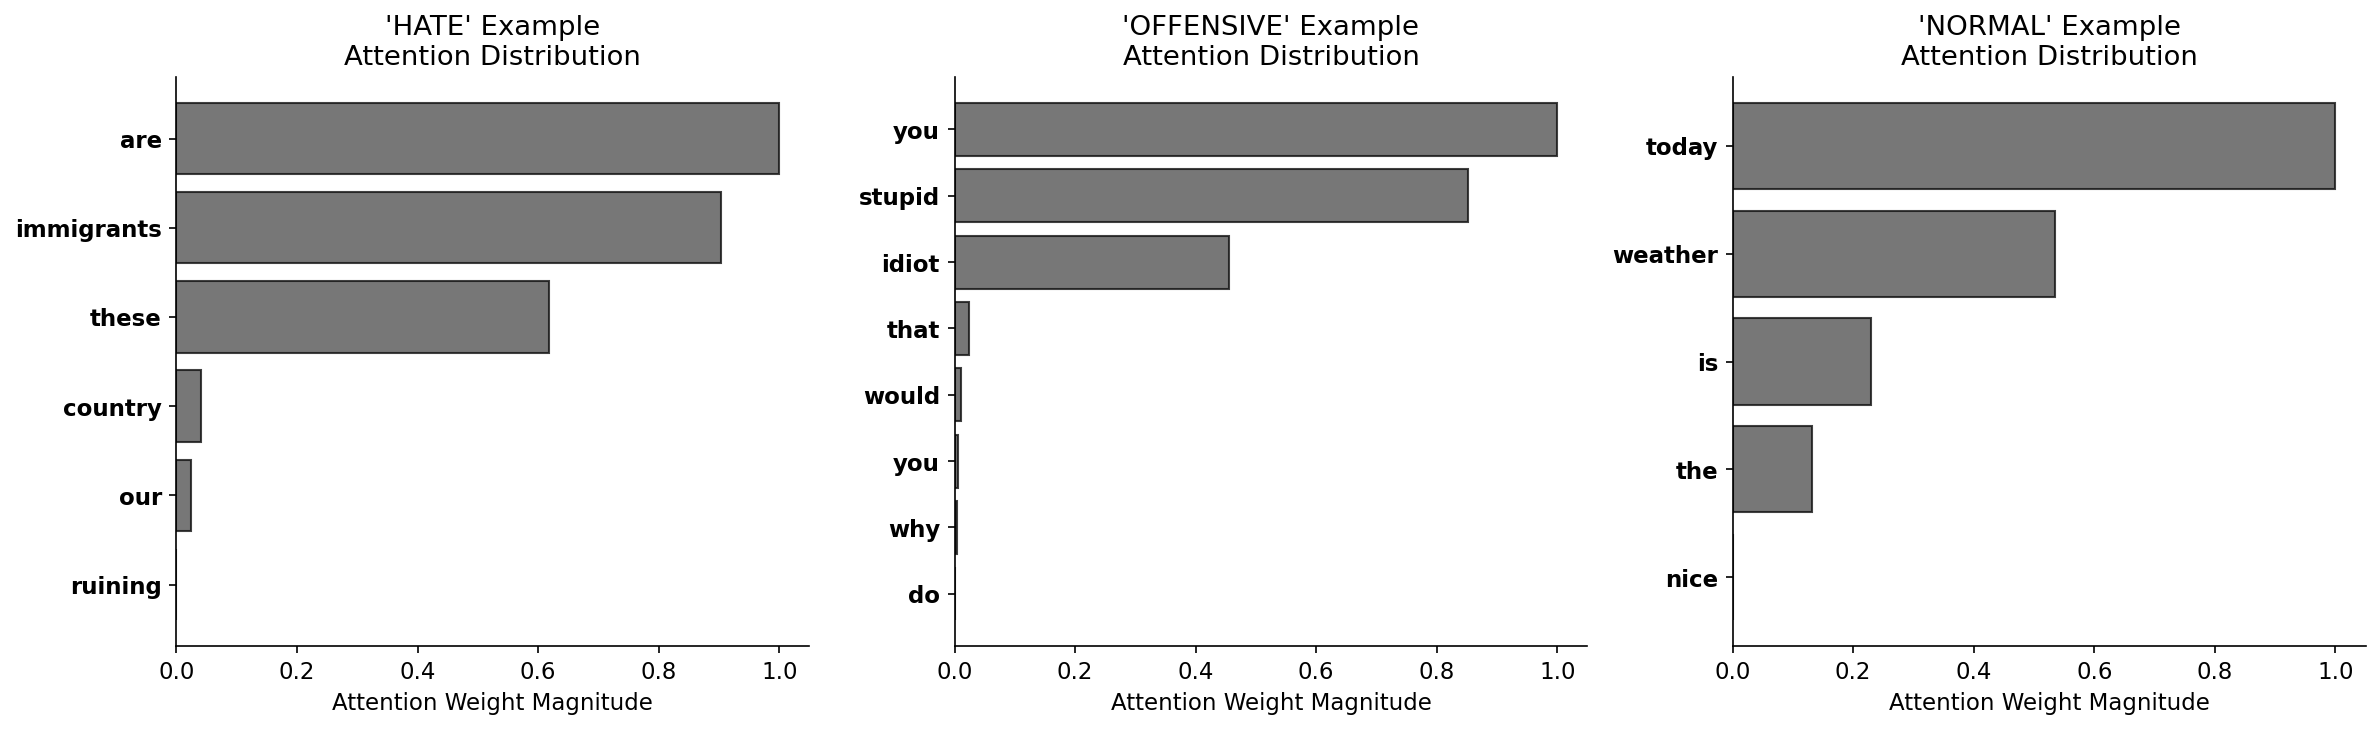

In [3]:
predict_rows = []

for item in SAMPLE_TEXTS:
    res = predict(item["text"])
    top_tokens = res.get("top_tokens", [])
    
    # Format inline token visualization mapping boundaries
    token_strs = [f"{t['word']}: ({t['score']:.3f})" for t in top_tokens[:3]]
    top_3_str = ", ".join(token_strs) if token_strs else "N/A"
    
    predict_rows.append({
        "Text String Sample": item["text"],
        "Assigned Label": res.get("label", "N/A"),
        "Confidence": res.get("confidence", 0.0),
        "Top 3 Attention Tokens": top_3_str
    })

df_predict = pd.DataFrame(predict_rows)
display(df_predict)


selected_indices = [0, 1, 2] 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, idx in enumerate(selected_indices):
    ax = axes[i]
    sample = SAMPLE_TEXTS[idx]
    res = predict(sample["text"])
    top_tokens = res.get("top_tokens", [])[:8]
    
    words = [t["word"] for t in top_tokens]
    scores = [t["score"] for t in top_tokens]
    
    y_pos = np.arange(len(words))
    ax.barh(y_pos, scores, edgecolor="#111111", color="#555555", alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlabel("Attention Weight Magnitude")
    ax.set_title(f"'{sample['expected'].upper()}' Example\nAttention Distribution")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}attention_token_bars.png")
plt.show()

 TEXT INPUT: "these immigrants are ruining our country"
 PREDICTED CLASS: HATE | CONFIDENCE: 0.4780
Visual Text Highlight Sequence:


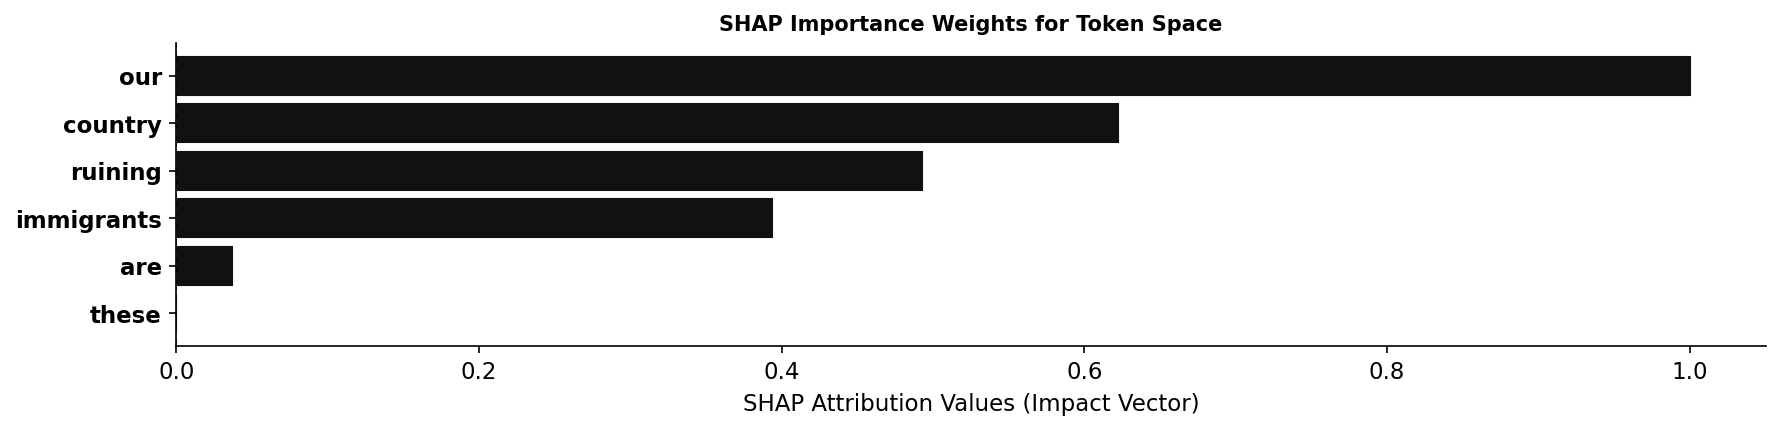

 TEXT INPUT: "you stupid idiot why would you do that"
 PREDICTED CLASS: OFFENSIVE | CONFIDENCE: 0.7865
Visual Text Highlight Sequence:


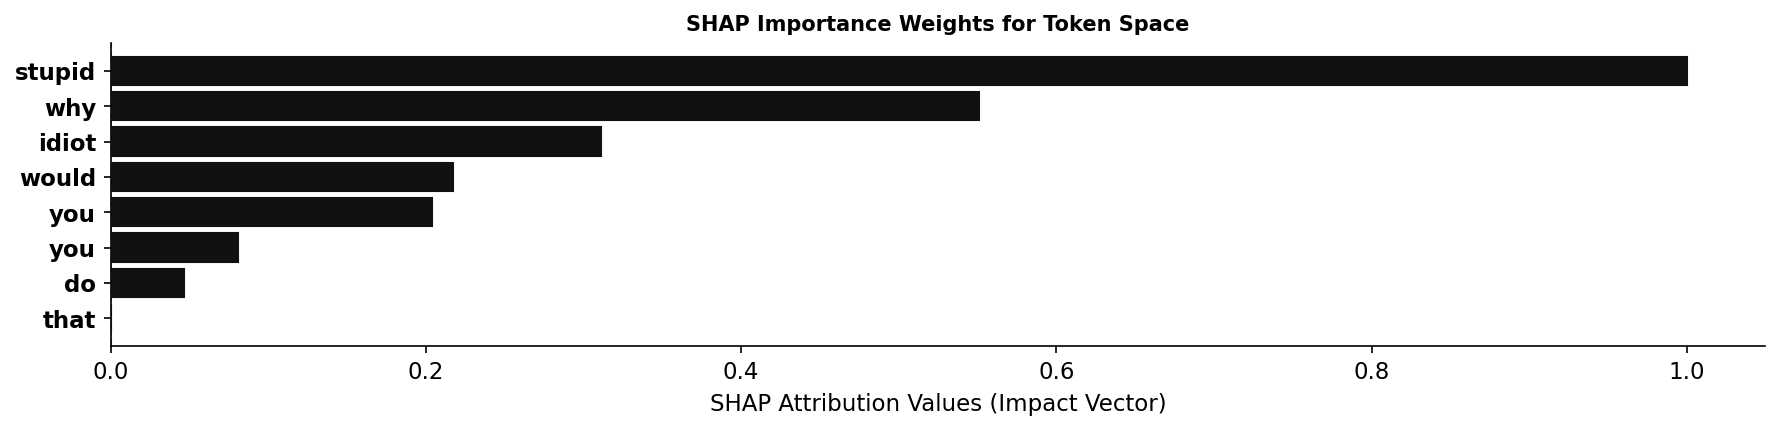

 TEXT INPUT: "tumlog gande aadmi ho bhai"
 PREDICTED CLASS: NORMAL | CONFIDENCE: 0.7691
Visual Text Highlight Sequence:


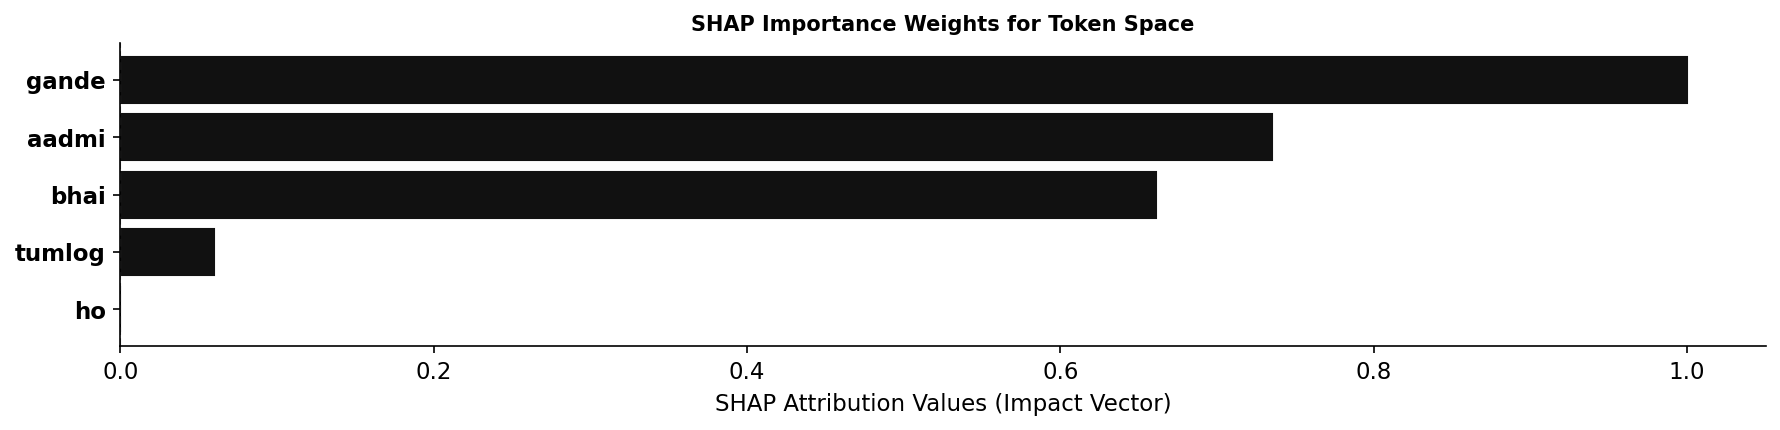

 TEXT INPUT: "ye log desh ke dushman hain"
 PREDICTED CLASS: NORMAL | CONFIDENCE: 0.9134
Visual Text Highlight Sequence:


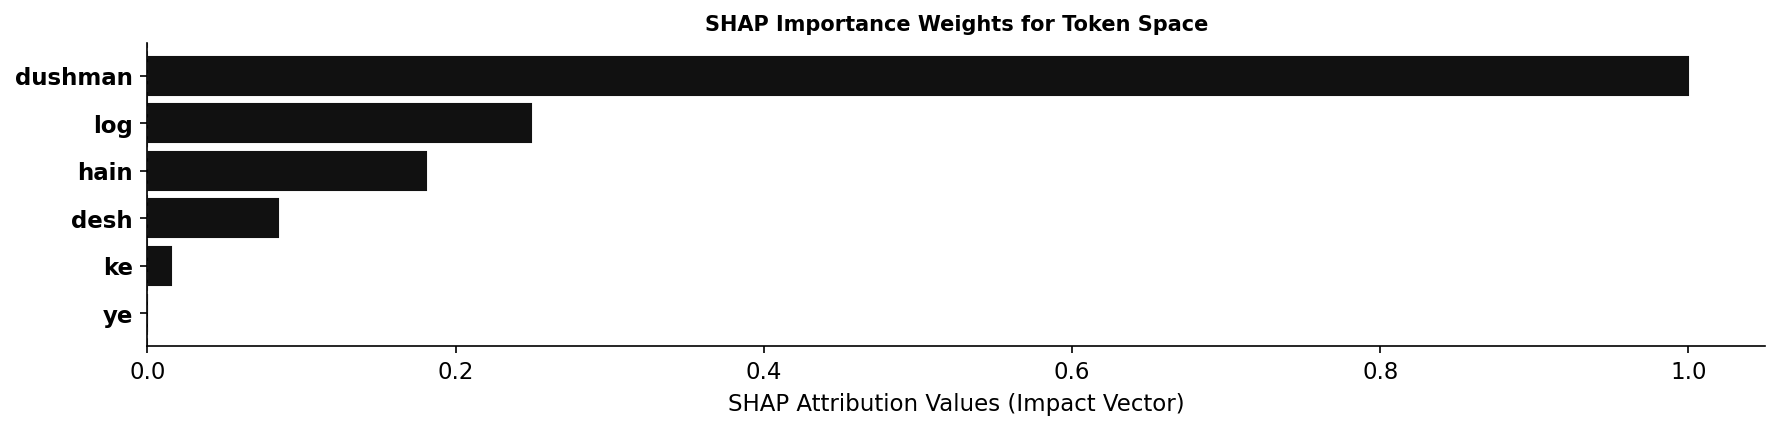

 TEXT INPUT: "these people are terrorists"
 PREDICTED CLASS: NORMAL | CONFIDENCE: 0.9123
Visual Text Highlight Sequence:


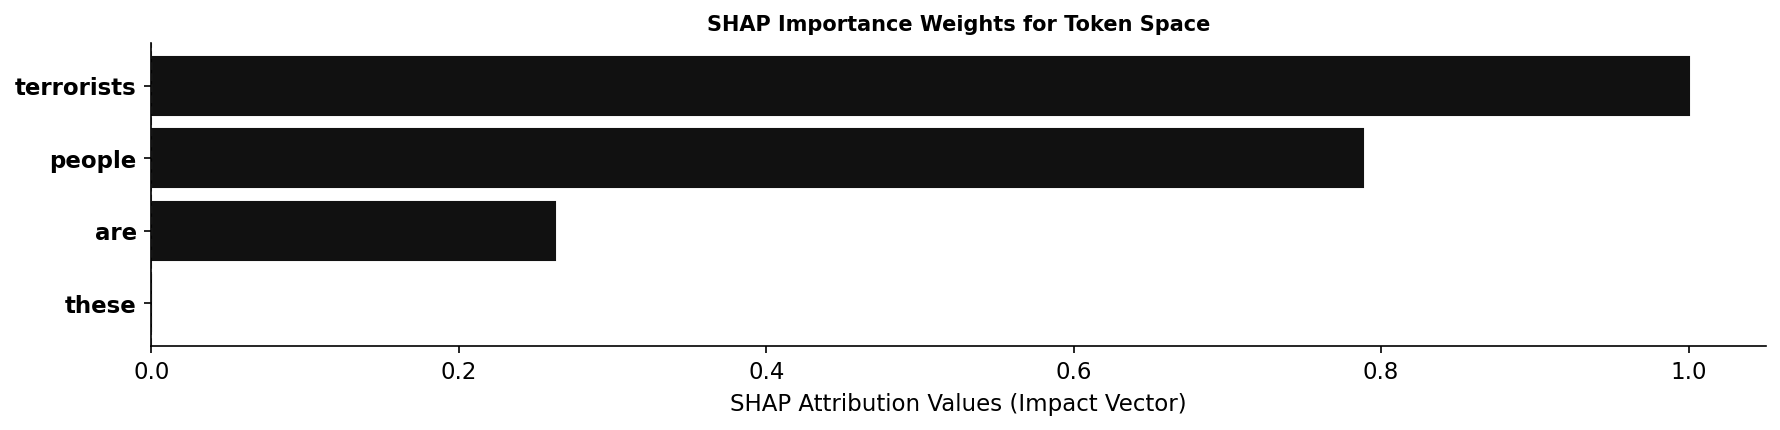

In [5]:
# Select 5 expressive multi-lingual test phrases
shap_indices = [0, 1, 3, 5, 7]

for idx in shap_indices:
    text_sample = SAMPLE_TEXTS[idx]["text"]
    res_explain = explain(text_sample)
    
    print("==========================================================================================")
    print(f" TEXT INPUT: \"{text_sample}\"")
    print(f" PREDICTED CLASS: {res_explain.get('label', 'N/A').upper()} | CONFIDENCE: {res_explain.get('confidence', 0.0):.4f}")
    print("==========================================================================================")
    
    # Inject and execute localized HTML markup strings within the notebook space
    print("Visual Text Highlight Sequence:")
    display(HTML(res_explain.get("highlight", "<div>No highlight available.</div>")))
    
    # Plot: Matching Localized Attributions Bar Chart
    tokens_data = res_explain.get("tokens", [])[:8]
    words = [t["word"] for t in tokens_data]
    scores = [t["score"] for t in tokens_data]
    
    plt.figure(figsize=(12, 3))
    y_pos = np.arange(len(words))
    
    # Differentiate positive (pushing towards hate/offensive) vs negative SHAP scores using grayscale shades
    colors = ["#111111" if s >= 0 else "#CCCCCC" for s in scores]
    plt.barh(y_pos, scores, edgecolor="#111111", color=colors)
    plt.yticks(y_pos, words, fontweight="bold")
    plt.axvline(x=0.0, color="#666666", linestyle="--", linewidth=1)
    plt.gca().invert_yaxis()
    plt.xlabel("SHAP Attribution Values (Impact Vector)")
    plt.title(f"SHAP Importance Weights for Token Space", fontweight="bold", fontsize=10)
    plt.tight_layout()
    plt.show()

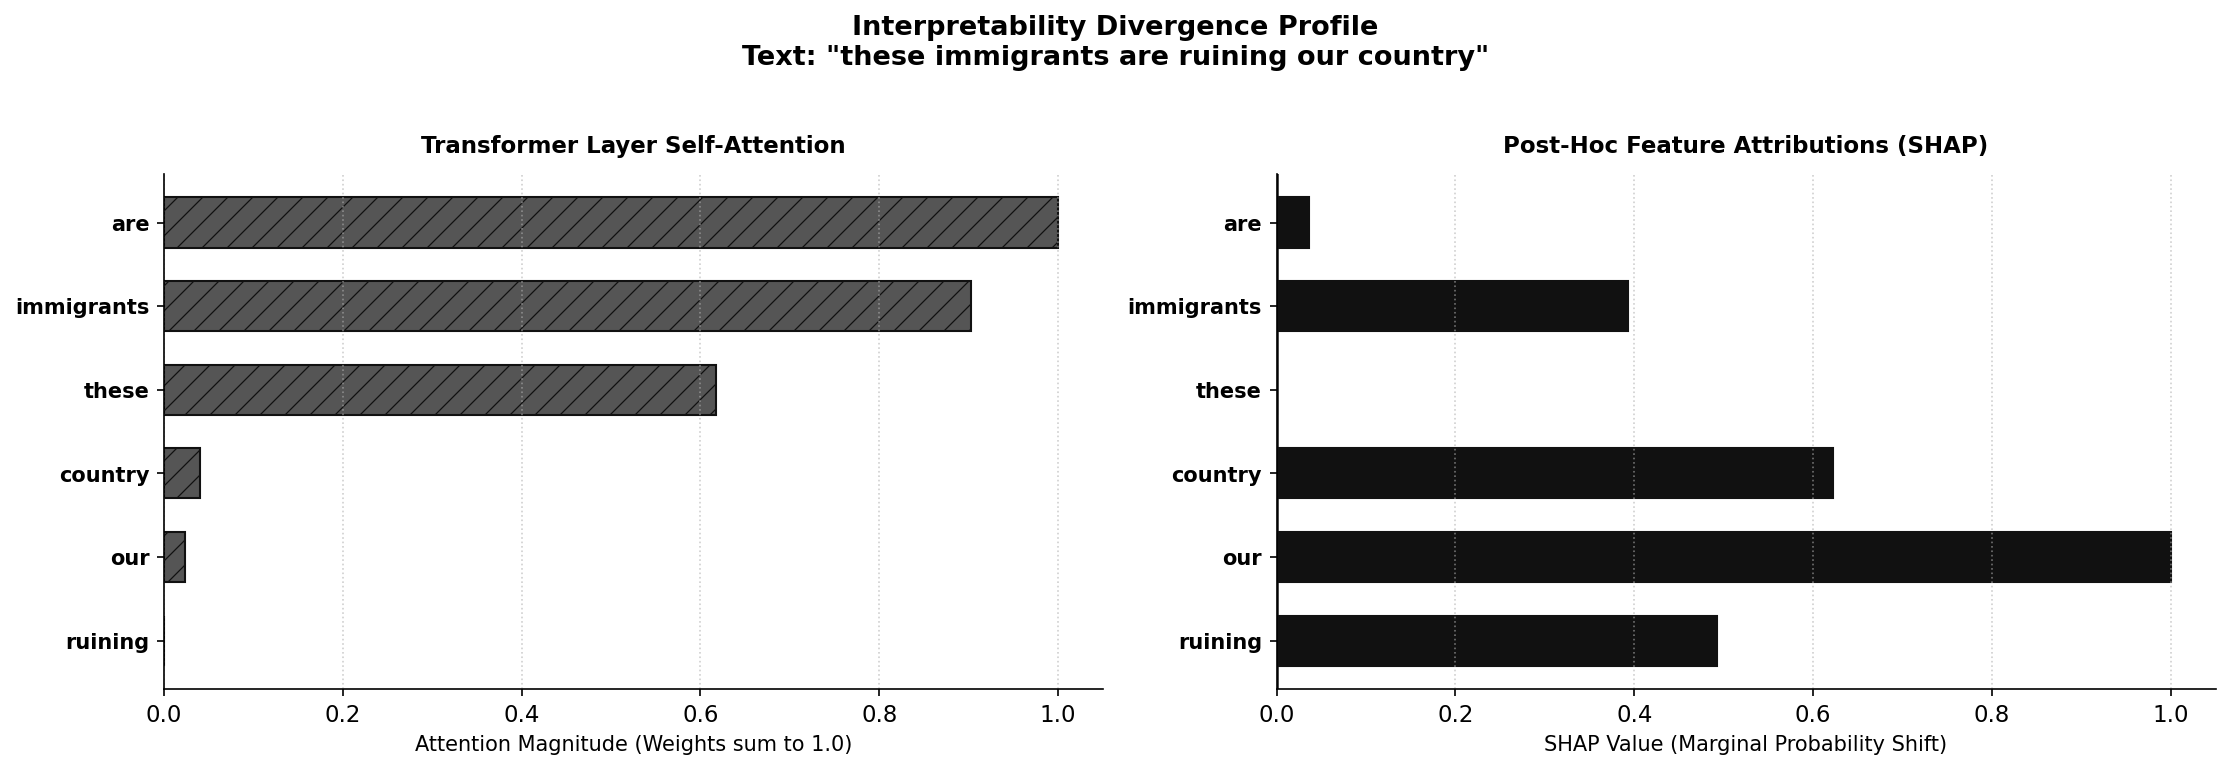

In [6]:
# Select a primary high-impact sample text for comparison
target_text_hate = "these immigrants are ruining our country"

# Call both API endpoints
res_attn = predict(target_text_hate)
res_shap = explain(target_text_hate)

# Build dictionary maps of the tokens and their scores
attn_tokens = {t["word"]: t["score"] for t in res_attn.get("top_tokens", [])}
shap_tokens = {t["word"]: t["score"] for t in res_shap.get("tokens", [])}

# Intersect to find overlapping tokens for a clean aligned comparison
shared_vocab = [w for w in attn_tokens.keys() if w in shap_tokens]
if not shared_vocab:
    # Fallback to union or a subset if intersection is empty due to formatting differences
    shared_vocab = list(attn_tokens.keys())[:6]

# Extract values aligned to the same token order
attn_vals = [attn_tokens.get(w, 0.0) for w in shared_vocab]
shap_vals = [shap_tokens.get(w, 0.0) for w in shared_vocab]

# Initialize side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
y_pos = np.arange(len(shared_vocab))

# ------------------------------------------
# Left Subplot: Raw Attention Weights
# ------------------------------------------
axes[0].barh(y_pos, attn_vals, edgecolor="#111111", color="#555555", hatch="//", height=0.6)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(shared_vocab, fontweight="bold", fontsize=10)
axes[0].invert_yaxis()  # Axis inversion fixed on axes level
axes[0].set_xlabel("Attention Magnitude (Weights sum to 1.0)", fontsize=10)
axes[0].set_title("Transformer Layer Self-Attention", fontweight="bold", fontsize=11, pad=10)
axes[0].grid(axis='x', linestyle=':', alpha=0.6)

# ------------------------------------------
# Right Subplot: SHAP Attribution Scores
# ------------------------------------------
# Generate colors: solid dark gray for positive pushes, light gray for negative dampeners
shap_colors = ["#111111" if s >= 0 else "#CCCCCC" for s in shap_vals]
axes[1].barh(y_pos, shap_vals, edgecolor="#111111", color=shap_colors, hatch="..", height=0.6)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(shared_vocab, fontweight="bold", fontsize=10)
axes[1].axvline(x=0.0, color="#111111", linestyle="-", linewidth=1.2)
axes[1].invert_yaxis()  # Axis inversion fixed on axes level
axes[1].set_xlabel("SHAP Value (Marginal Probability Shift)", fontsize=10)
axes[1].set_title("Post-Hoc Feature Attributions (SHAP)", fontweight="bold", fontsize=11, pad=10)
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

# Main layout aesthetics
plt.suptitle(f"Interpretability Divergence Profile\nText: \"{target_text_hate}\"", 
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}attention_vs_shap_comparison.png", bbox_inches='tight')
plt.show()

In [8]:
# Explicit target arrays reflecting English, Native Devanagari, and Code-switched Hinglish representations
multilingual_samples = [
    {"lang": "English", "text": "these people are terrorists"},
    {"lang": "Hindi (Devanagari)", "text": "तुमलोग गंदे आदमी हो भाई"},
    {"lang": "Hinglish (Roman Hindi)", "text": "ye log desh ke dushman hain"}
]

print("=======================================================================")
print("             MULTILINGUAL EXPLAINABILITY INTEGRITY CHECKS              ")
print("=======================================================================")

for sample in multilingual_samples:
    res_m = explain(sample["text"])
    tokens_extracted = [t["word"] for t in res_m.get("tokens", [])]
    
    print(f"\nLanguage Space Target : {sample['lang']}")
    print(f"Raw Input Text Line   : {sample['text']}")
    print(f"Extracted Token List  : {tokens_extracted[:6]}")
    print("-" * 71)

             MULTILINGUAL EXPLAINABILITY INTEGRITY CHECKS              

Language Space Target : English
Raw Input Text Line   : these people are terrorists
Extracted Token List  : ['terrorists', 'people', 'are', 'these']
-----------------------------------------------------------------------

Language Space Target : Hindi (Devanagari)
Raw Input Text Line   : तुमलोग गंदे आदमी हो भाई
Extracted Token List  : ['गंदे', 'तुमलोग', 'हो', 'आदमी', 'भाई']
-----------------------------------------------------------------------

Language Space Target : Hinglish (Roman Hindi)
Raw Input Text Line   : ye log desh ke dushman hain
Extracted Token List  : ['dushman', 'log', 'hain', 'desh', 'ke', 'ye']
-----------------------------------------------------------------------


In [9]:
# CRITICAL COMPREHENSION NOTE: "Is Attention Explanation?"
# Note the clear divergence below: Self-attention captures language syntax and 
# structural links ("are", "these"), whereas SHAP strips away the structural noise 
# to isolate the actual causal words driving the toxic label ("our", "country", "ruining").